<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L1B_L2A_L2B_Native_EO_Res_Multi_Branch_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio torch tqdm matplotlib timm torchmetrics --quiet
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'data_32_32_patches_11_4_25',
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    "model_animations",
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/model_animations
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface


# Sort Find Prep data

In [4]:
import os

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)


Output directory: /content/processed_32x32_normalized


In [5]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"


In [6]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [7]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2A":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [8]:
split_counts = Counter(splits)
split_counts


Counter({'train': 1777, 'test': 426, 'val': 211})

In [9]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2A")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)


Found 2414 TIFFs with product_field = GEDI_L2A

Split counts:
train: 1777
test: 426
val: 211

First 10 selected TIFFs:
landsatidx_train_GEDI_L2A_2022358084911_1190_block_5923887.tif
landsatidx_train_GEDI_L2A_2020196021509_1429_block_5943897.tif
landsatidx_test_GEDI_L2A_2022358084911_1692_block_5943888.tif
landsatidx_train_GEDI_L2A_2020196021509_966_block_5933897.tif
landsatidx_test_GEDI_L2A_2021135083748_1487_block_5933898.tif
s2idx_train_GEDI_L2A_2022358084911_799_block_5983894.tif
s2idx_train_GEDI_L2A_2022358084911_1213_block_5933888.tif
s2idx_train_GEDI_L2A_2021135083748_1176_block_6033889.tif
s2idx_test_GEDI_L2A_2022358084911_1755_block_5983892.tif
s2idx_test_GEDI_L2A_2022358084911_1757_block_5983892.tif


# Move Selected files

In [10]:
import os
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"
PROCESSED_DIR = "/content/processed_32x32_normalized"

os.makedirs(PROCESSED_DIR, exist_ok=True)

moved = 0
missing = 0

for fname in selected_files:
    src = os.path.join(RASTER_DIR, fname)
    dst = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)   # or use shutil.move(src, dst) if you want to REMOVE originals
        moved += 1
    else:
        print("❗ MISSING FILE:", fname)
        missing += 1

print("=====================================")
print("Selected files moved:", moved)
print("Missing source files:", missing)
print("Destination folder:", PROCESSED_DIR)


Selected files moved: 2414
Missing source files: 0
Destination folder: /content/processed_32x32_normalized


# Investigate a set of Tifs before modifying/prepping

In [11]:
import random

sample_files = random.sample(selected_files, 5)
sample_files


['s2_train_GEDI_L2A_2021135083748_1533_block_5953896.tif',
 'landsatidx_train_GEDI_L2A_2022358084911_1357_block_6033898.tif',
 's2_train_GEDI_L2A_2022358084911_1708_block_5953889.tif',
 'dem_test_GEDI_L2A_2022139064237_196_block_5923889.tif',
 'hls_train_GEDI_L2A_2022358084911_1293_block_6003895.tif']


FILE: s2_train_GEDI_L2A_2021135083748_1533_block_5953896.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.03220000118017197
      max:  0.060883332043886185
      mean: 0.0468415105809467
      std:  0.005295483725359663

  Band 2 statistics:
      min:  0.036407142877578735
      max:  0.05004444345831871
      mean: 0.043830571140276386
      std:  0.002252850406325086

  Band 3 statistics:
      min:  0.025276923552155495
      max:  0.03611428663134575
      mean: 0.029704189258118744
      std:  0.0015635822661190883

  Band 4 statistics:
      min:  0.1876000016927719
      max:  0.3338499963283539
      mean: 0.2429606174798708
      std:  0.02692607752887322

  Band 5 statistics:
      min:  0.16635000705718994
      max:  0.2132333368062973
      mean: 0.1914696503495601
      std:  0.00756718034405306

  Band 6 statistics:
      min:  0.07270000129938126
      max:  0.1152999997138977
 

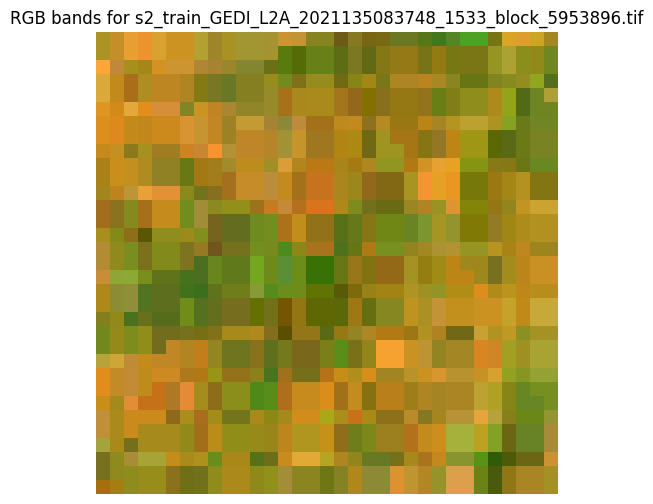


FILE: landsatidx_train_GEDI_L2A_2022358084911_1357_block_6033898.tif
BANDS: 7
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  -0.5115678310394287
      max:  0.8638620376586914
      mean: 0.5643587330835182
      std:  0.24818876995665404

  Band 2 statistics:
      min:  -0.7938501834869385
      max:  0.5518955588340759
      mean: -0.5714728147814087
      std:  0.20200301687237462

  Band 3 statistics:
      min:  -0.6915212273597717
      max:  0.6761546730995178
      mean: -0.5048967270369835
      std:  0.1542793084371489

  Band 4 statistics:
      min:  -0.16637688875198364
      max:  0.5730642080307007
      mean: 0.3273123933313416
      std:  0.1394382883905986

  Band 5 statistics:
      min:  -0.21819956600666046
      max:  0.4214884638786316
      mean: 0.11805486269368105
      std:  0.13545106189902953

  Band 6 statistics:
      min:  -0.4214884638786316
      max:  0.21819956600666046
  

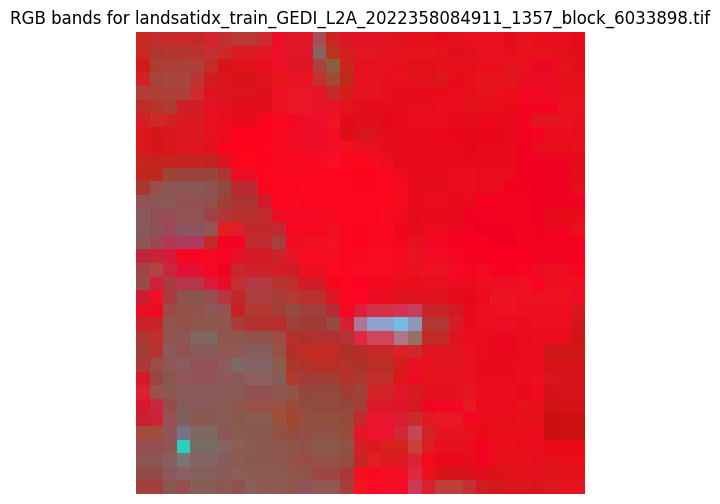


FILE: s2_train_GEDI_L2A_2022358084911_1708_block_5953889.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.0260624997317791
      max:  0.07100000232458115
      mean: 0.04300402730696512
      std:  0.006623078970580648

  Band 2 statistics:
      min:  0.03830000013113022
      max:  0.07524000108242035
      mean: 0.051947331652934664
      std:  0.005191375751252411

  Band 3 statistics:
      min:  0.026085713878273964
      max:  0.05756666511297226
      mean: 0.035351510309332874
      std:  0.004531899803550077

  Band 4 statistics:
      min:  0.15600000321865082
      max:  0.2941499948501587
      mean: 0.22387784677048797
      std:  0.021697518333045722

  Band 5 statistics:
      min:  0.13897499442100525
      max:  0.24895000457763672
      mean: 0.20288634572530473
      std:  0.01718482718775415

  Band 6 statistics:
      min:  0.0737999975681305
      max:  0.14350000023841858

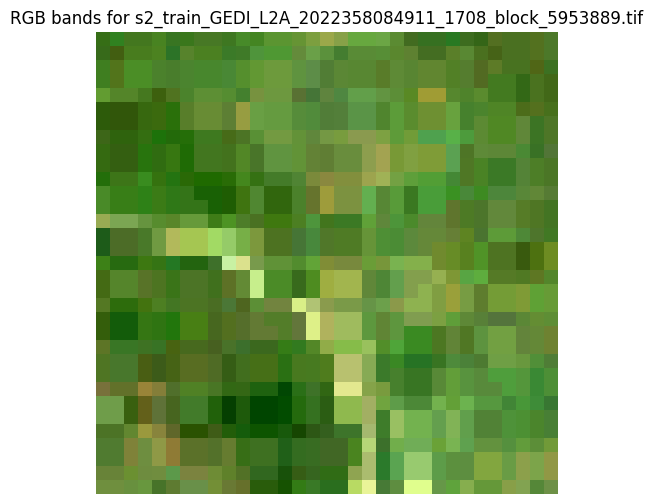


FILE: dem_test_GEDI_L2A_2022139064237_196_block_5923889.tif
BANDS: 2
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  439.4967041015625
      max:  576.4371337890625
      mean: 511.27087258731615
      std:  33.68313278985071

  Band 2 statistics:
      min:  1.9230207204818726
      max:  26.60405731201172
      mean: 13.1582118467373
      std:  4.1983245339570265
Skipping visualization for dem_test_GEDI_L2A_2022139064237_196_block_5923889.tif: not enough bands for RGB or single band.


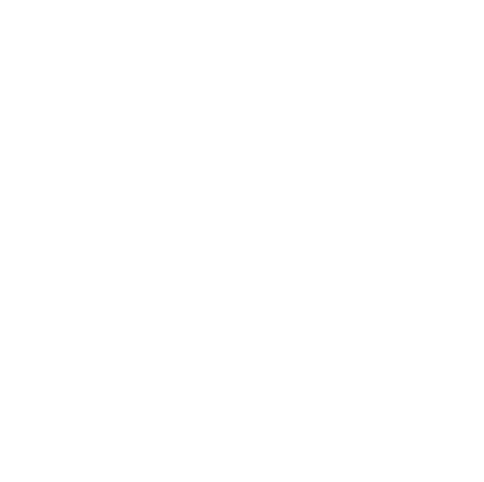


FILE: hls_train_GEDI_L2A_2022358084911_1293_block_6003895.tif
BANDS: 7
SIZE (pixels): 34 x 34
TOTAL PIXELS: 1156
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.20141050219535828
      max:  0.8049033284187317
      mean: 0.6868091802335116
      std:  0.054488462760740874

  Band 2 statistics:
      min:  -0.7788913249969482
      max:  -0.3110004663467407
      mean: -0.674950477419015
      std:  0.04861911351513912

  Band 3 statistics:
      min:  -0.6844974160194397
      max:  -0.19944597780704498
      mean: -0.5875789329126013
      std:  0.03303862562373325

  Band 4 statistics:
      min:  0.12492693960666656
      max:  0.49909737706184387
      mean: 0.3566445168430005
      std:  0.043334288425295714

  Band 5 statistics:
      min:  -0.1390806883573532
      max:  0.3272807002067566
      mean: 0.14738869140161856
      std:  0.06753224022838665

  Band 6 statistics:
      min:  -0.3272807002067566
      max:  0.1390806883573532
     

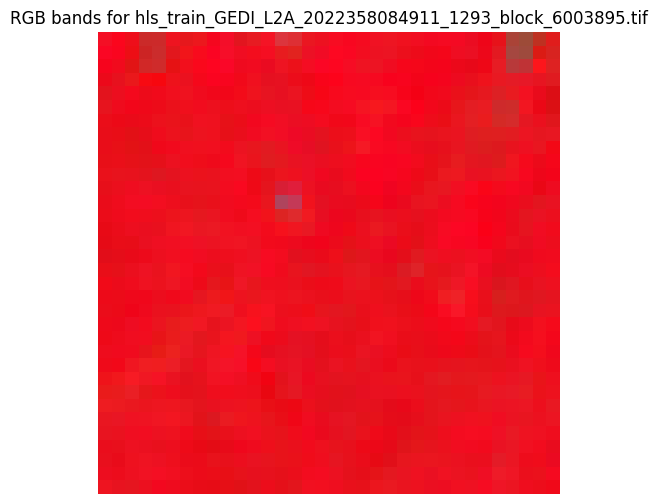

In [12]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

# Prep tifs: Pad, Normalize, inspect, save to content

In [13]:
from rasterio.enums import Resampling

def resize_to_max32(src):
    """
    Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
    Returns a numpy array (bands, new_h, new_w).
    """
    h = src.height
    w = src.width
    bands = src.count

    # No resizing needed
    if h <= 32 and w <= 32:
        return src.read()

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    return resized


In [14]:
import numpy as np

def pad_to_32x32(arr):
    """Center-pad a raster to exactly (bands, 32, 32)."""
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr
    return padded


In [15]:
def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr


In [16]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0
dropped_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []   # <-- Files that pass checks
dropped_list = []     # <-- Files to delete


for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False
        too_many_nans = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True
            if nan_count >= 100:
                too_many_nans = True

            bands.append(data)

    # Drop files with too many NaNs
    if too_many_nans:
        dropped_files += 1
        dropped_list.append(fname)     # <--- NOW correctly recorded
        print(f"DROPPED: {fname} (≥100 NaNs)")
        continue

    # Fix files that have ≤99 NaNs
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                med = np.nanmedian(data)
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep this TIFF for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

print("Dropped files:", dropped_list)

# -------------------------------------------------------------------------
# DELETE DROPPED FILES
# -------------------------------------------------------------------------
print("\nDeleting dropped TIFF files...\n")

for fname in dropped_list:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        os.remove(fpath)
        print("Deleted:", fname)

print("\nFinished deleting dropped TIFFs.")
print("Total deleted files:", len(dropped_list))


Scanning directory: /content/processed_32x32_normalized

Found 2414 TIFFs in /content/processed_32x32_normalized

DROPPED: s1_train_GEDI_L2A_2020196021509_1368_block_5913894.tif (≥100 NaNs)
DROPPED: s2_train_GEDI_L2A_2022358084911_1364_block_6033898.tif (≥100 NaNs)
DROPPED: hls_train_GEDI_L2A_2021135083748_53_block_5953899.tif (≥100 NaNs)
DROPPED: landsatidx_train_GEDI_L2A_2020196021509_923_block_5923895.tif (≥100 NaNs)
DROPPED: s2_test_GEDI_L2A_2020196021509_1473_block_5973899.tif (≥100 NaNs)
DROPPED: landsatidx_train_GEDI_L2A_2020196021509_995_block_5963899.tif (≥100 NaNs)
DROPPED: landsatidx_test_GEDI_L2A_2022139064237_231_block_5933887.tif (≥100 NaNs)
DROPPED: s1_test_GEDI_L2A_2022139064237_194_block_5923889.tif (≥100 NaNs)
DROPPED: dem_train_GEDI_L2A_2022358084911_713_block_5923888.tif (≥100 NaNs)
DROPPED: dem_train_GEDI_L2A_2021135083748_681_block_6033891.tif (≥100 NaNs)
DROPPED: s2_test_GEDI_L2A_2022139064237_233_block_5933887.tif (≥100 NaNs)
FIXING: hls_train_GEDI_L2A_202113508

In [17]:
processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired

    with rasterio.open(src_path) as src:

        # Step 1: Resize
        resized = resize_to_max32(src)

        # Step 2: Pad
        padded = pad_to_32x32(resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile
        profile.update({
            "height": 32,
            "width": 32,
            "transform": rasterio.transform.from_origin(0, 0, 1, 1),
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Processed 2186 TIFFs successfully.


comp. before preprocessing

In [ ]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")


⚠️ WARNING: Processed version not found for hls_train_GEDI_L2A_2021135083748_54_block_5953899.tif



PROCESSED FILE: s2_test_GEDI_L2A_2021135083748_1168_block_6033890.tif
LOCATION: /content/processed_32x32_normalized/s2_test_GEDI_L2A_2021135083748_1168_block_6033890.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.21061446435260223
      std:  0.07661745027981158

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.09769212593255361
      std:  0.0649484445869031

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.06321276038352153
      std:  0.056517759187495596

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.2842253062376585
      std:  0.12301363126196017

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43565329564353306
      std:  0.13666338229058136

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.26031326604788774
      std:  0.10648740452941247


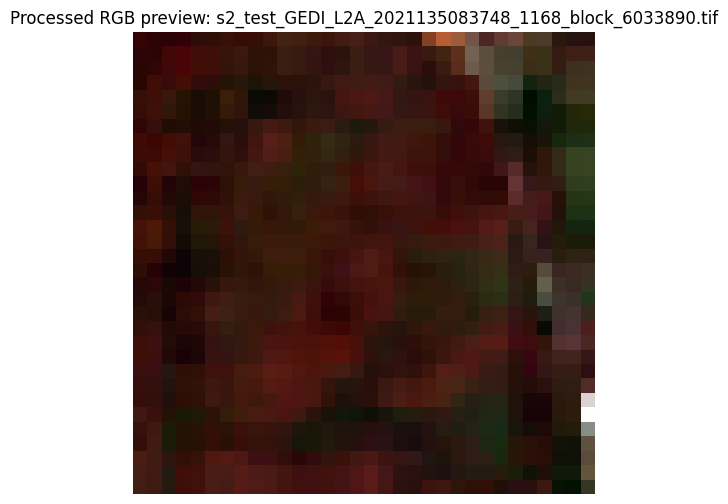


PROCESSED FILE: s1_test_GEDI_L2A_2021135083748_160_block_6013894.tif
LOCATION: /content/processed_32x32_normalized/s1_test_GEDI_L2A_2021135083748_160_block_6013894.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7671275801203592
      std:  0.1962841689264706

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7829712255734194
      std:  0.19633152008524038

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3813653833367425
      std:  0.18114760885504896

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4221003583061247
      std:  0.17808984395349597


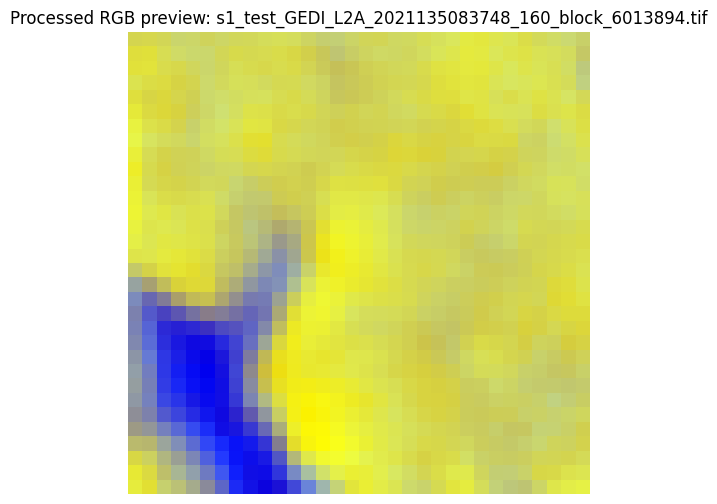


PROCESSED FILE: landsat_train_GEDI_L2A_2021135083748_1509_block_5943897.tif
LOCATION: /content/processed_32x32_normalized/landsat_train_GEDI_L2A_2021135083748_1509_block_5943897.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5223797852281677
      std:  0.19477674210319793

  Band 2 statistics:
      min:  0.0
      max:  0.9999999403953552
      mean: 0.5383294088424009
      std:  0.13775368384543518

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5351857907644444
      std:  0.17285741477431693

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.41901047692545035
      std:  0.18033113466050674

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.508549316112294
      std:  0.18823161404922903

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5852039242113278
      std:  0.21095700674629927


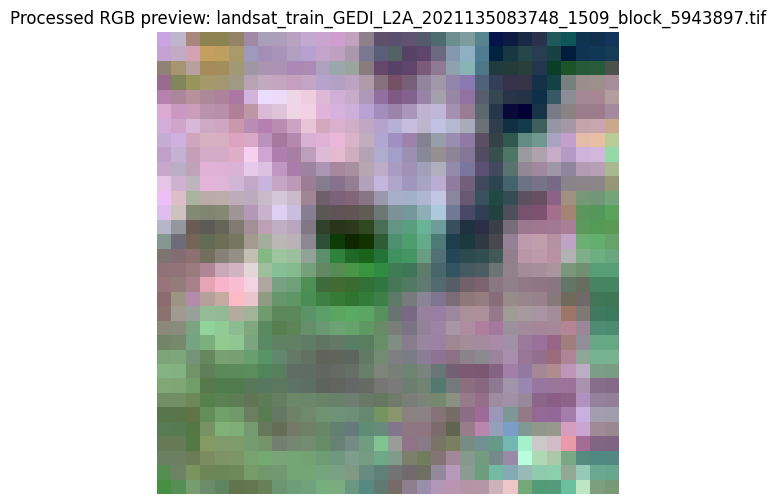


PROCESSED FILE: s1_train_GEDI_L2A_2021135083748_1572_block_5983893.tif
LOCATION: /content/processed_32x32_normalized/s1_train_GEDI_L2A_2021135083748_1572_block_5983893.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5262759575070959
      std:  0.17463695872527984

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6014077600157179
      std:  0.16307540048480695

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5672658807816333
      std:  0.1485311288968884

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5994439465612231
      std:  0.14656376477067629


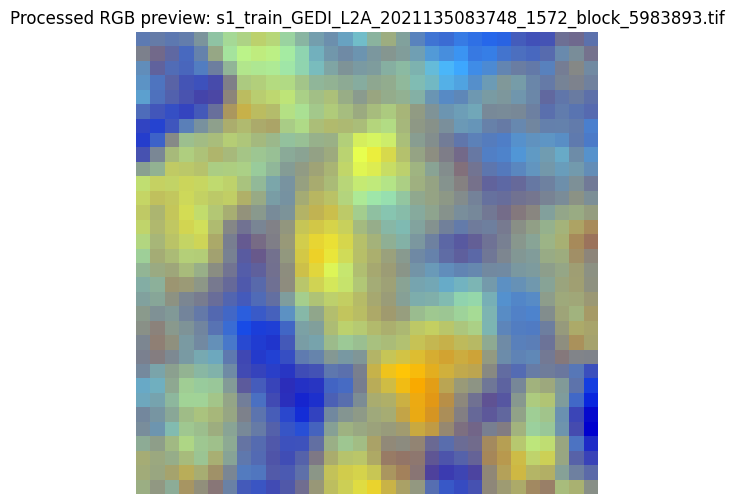

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


# Target filter

In [18]:
import pandas as pd

GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# Load CSV
df = pd.read_csv(GEDI_CSV)

# Filter for product_field == "GEDI_LSA"
df_filtered_GEDI_L2A = df[df["product_field"] == "GEDI_L2A"]

df_filtered_GEDI_L2A


/tmp/ipython-input-686974334.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217155,-85.859947,549.746216,567.769958,-41.230606,0.977462,0.0,1.0,...,NaN,NaN,NaN,603758.425670,3.897721e+06,603,3897,603_3897,1864,train
1864,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217505,-85.859484,550.669312,566.905273,-41.230209,0.975680,0.0,1.0,...,NaN,NaN,NaN,603800.146408,3.897760e+06,603,3897,603_3897,1865,train
1865,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217854,-85.859021,549.173706,566.905273,-41.229813,0.978489,0.0,1.0,...,NaN,NaN,NaN,603841.799971,3.897799e+06,603,3897,603_3897,1866,train
1866,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,NaN,NaN,NaN,603925.187830,3.897878e+06,603,3897,603_3897,1867,train


# Pair Tif and GEDI Obs (Targets)

In [19]:
import re

FILENAME_RE = re.compile(
    r"^(?P<cov>[a-zA-Z0-9]+)_"          # covariate (s1, s2, landsatidx, etc)
    r"(?P<split>train|test|val)_"       # split
    r"GEDI_L2A_"                        # product field (constant)
    r"(?P<shot>\d+)_"                   # shot
    r"(?P<row_ID>\d+)_"                 # row_ID
    r"block_(?P<block_id>\d+)\.tif$"    # block_id
)


In [20]:
import os
import pandas as pd

TIFF_ROOT = "/content/processed_32x32_normalized"

rows = []

for fn in os.listdir(TIFF_ROOT):
    if not fn.endswith(".tif"):
        continue

    m = FILENAME_RE.match(fn)
    if m is None:
        print("WARNING: filename did not match pattern:", fn)
        continue

    d = m.groupdict()
    d["filename"] = fn
    d["full_path"] = os.path.join(TIFF_ROOT, fn)
    rows.append(d)

tif_df = pd.DataFrame(rows)
print("Parsed TIFFs:", len(tif_df))
print(tif_df.head())


Parsed TIFFs: 2186
    cov  split           shot row_ID block_id  \
0    s2  train  2021135083748    619  6003894   
1    s2  train  2022358084911   1340  6023897   
2  tcap  train  2021135083748   1508  5943897   
3    s2  train  2020196021509    972  5943897   
4   dem  train  2021135083748     99  5983896   

                                            filename  \
0  s2_train_GEDI_L2A_2021135083748_619_block_6003...   
1  s2_train_GEDI_L2A_2022358084911_1340_block_602...   
2  tcap_train_GEDI_L2A_2021135083748_1508_block_5...   
3  s2_train_GEDI_L2A_2020196021509_972_block_5943...   
4  dem_train_GEDI_L2A_2021135083748_99_block_5983...   

                                           full_path  
0  /content/processed_32x32_normalized/s2_train_G...  
1  /content/processed_32x32_normalized/s2_train_G...  
2  /content/processed_32x32_normalized/tcap_train...  
3  /content/processed_32x32_normalized/s2_train_G...  
4  /content/processed_32x32_normalized/dem_train_...  


In [21]:
print("\nTIFF counts per covariate:")
print(tif_df["cov"].value_counts())



TIFF counts per covariate:
cov
s2            514
tcap          260
dem           260
landsatidx    260
landsat       260
hls           258
s1            237
s2idx         137
Name: count, dtype: int64


In [22]:
df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)
tif_df["row_ID"] = tif_df["row_ID"].astype(int)

merged = df_filtered_GEDI_L2A.merge(tif_df, on="row_ID", how="left")


/tmp/ipython-input-1886280410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)


In [23]:
valid = merged[~merged["filename"].isna()]
print("GEDI L2A rows:", len(df_filtered_GEDI_L2A))
print("Rows with matching TIFFs:", len(valid["row_ID"].unique()))


GEDI L2A rows: 1868
Rows with matching TIFFs: 663


In [24]:
df_valid = pd.DataFrame(valid)

In [25]:
df_valid

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,block_y,block_id_x,row_ID,split_x,cov,split_y,shot,block_id_y,filename,full_path
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,s1,val,2020196021509,5923897,s1_val_GEDI_L2A_2020196021509_4_block_5923897.tif,/content/processed_32x32_normalized/s1_val_GED...
6,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.217882,-85.984680,504.926117,517.720337,-18.850962,0.976463,0.0,1.0,...,3897,592_3897,7,val,s2,val,2020196021509,5923897,s2_val_GEDI_L2A_2020196021509_7_block_5923897.tif,/content/processed_32x32_normalized/s2_val_GED...
10,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219275,-85.982846,511.952362,524.200256,-18.851089,0.974180,0.0,1.0,...,3897,592_3897,11,val,s2,val,2020196021509,5923897,s2_val_GEDI_L2A_2020196021509_11_block_5923897...,/content/processed_32x32_normalized/s2_val_GED...
11,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219631,-85.982373,499.648376,505.862122,-18.851122,0.990057,0.0,1.0,...,3897,592_3897,12,val,landsat,val,2020196021509,5923897,landsat_val_GEDI_L2A_2020196021509_12_block_59...,/content/processed_32x32_normalized/landsat_va...
12,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219631,-85.982373,499.648376,505.862122,-18.851122,0.990057,0.0,1.0,...,3897,592_3897,12,val,dem,val,2020196021509,5923897,dem_val_GEDI_L2A_2020196021509_12_block_592389...,/content/processed_32x32_normalized/dem_val_GE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.213315,-85.865033,555.326599,574.336975,-41.234959,0.968937,0.0,1.0,...,3897,603_3897,1853,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1853_block_603...,/content/processed_32x32_normalized/s2_train_G...
3377,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.214012,-85.864110,555.053955,566.020325,-41.234169,0.970757,0.0,1.0,...,3897,603_3897,1855,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1855_block_603...,/content/processed_32x32_normalized/s2_train_G...
3380,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.215059,-85.862724,550.813904,554.111755,-41.232986,0.973757,0.0,1.0,...,3897,603_3897,1858,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1858_block_603...,/content/processed_32x32_normalized/s2_train_G...
3383,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.216107,-85.861335,552.883972,555.467957,-41.231796,0.979334,0.0,1.0,...,3897,603_3897,1861,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1861_block_603...,/content/processed_32x32_normalized/s2_train_G...


In [ ]:
# df_valid.to_csv('df_valid.csv', index=False)

In [26]:
column_names = valid.columns.tolist()
print(column_names)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta',

In [27]:
eo_list = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

print("\nCounts per EO by split:")
for eo in eo_list:
    eo_df = tif_df[tif_df["cov"] == eo]
    print(f"\nEO = {eo}")
    print(eo_df["split"].value_counts())



Counts per EO by split:

EO = s1
split
train    165
test      48
val       24
Name: count, dtype: int64

EO = s2
split
train    371
test      92
val       51
Name: count, dtype: int64

EO = landsat
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = landsatidx
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = hls
split
train    192
test      42
val       24
Name: count, dtype: int64

EO = tcap
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = dem
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = s2idx
split
train    104
test      22
val       11
Name: count, dtype: int64


# Data loaders

In [28]:
EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
SPATIAL_RES = {
    's1': 10, 's2': 20, 's2idx': 20,
    'landsat': 30, 'landsatidx': 30,
    'hls': 30, 'tcap': 30, 'dem': 30
}
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

In [60]:
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import random


# -----------------------
# Remove NaN samples
# -----------------------
def drop_nan_samples(df):
    clean_rows = []
    dropped = 0

    for i, row in df.iterrows():
        fp = row["full_path"]
        try:
            with rasterio.open(fp) as src:
                arr = src.read().astype(np.float32)
                if np.isnan(arr).any():
                    dropped += 1
                    continue
        except:
            dropped += 1
            continue

        clean_rows.append(row)

    clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
    print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
    return clean_df

# -----------------------
# Dataset for a single EO
# -----------------------
class GeoTiffDataset(Dataset):
    def __init__(self, df, eo, bands_per_cov, target_col='rh', transform=None, augment=False, split='train'):
        """
        Single-EO Dataset for multibranch model.
        df: pandas DataFrame
        eo: EO type (string, must match 'cov' column)
        bands_per_cov: dict mapping EO type to number of bands
        target_col: target column name
        transform: optional transform
        augment: whether to apply flips and rotations
        split: data partition ('train', 'val', 'test')
        """
        # Filter rows by EO and split
        self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
        self.eo = eo
        self.bands = bands_per_cov[eo]
        self.target_col = target_col
        self.transform = transform
        self.augment = augment

        if len(self.df) == 0:
            print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
        else:
            print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
        print(f"[INFO] Target column: {self.target_col}")
        print(f"[INFO] Augmentation enabled: {self.augment}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row['full_path']

        with rasterio.open(fp) as src:
            arr = src.read().astype(np.float32)  # (C, H, W)

        # Verify band count
        if arr.shape[0] != self.bands:
            raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

        # Augmentation: flips and rotations
        if self.augment:
            if random.random() > 0.5:  # horizontal flip
                arr = arr[:, :, ::-1].copy()
            if random.random() > 0.5:  # vertical flip
                arr = arr[:, ::-1, :].copy()
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()

        if self.transform:
            arr = self.transform(arr)

        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(row[self.target_col], dtype=torch.float32)

        # return x, y
        return {
        "image": x,      #
        "target": y,     #
        "path": fp       # 11/20 !!!! NEW — adds full file path for embedding fusion
    }

# -----------------------
# Function to create loaders per EO and split
# -----------------------
def create_multibranch_loaders(df, eo_list, bands_per_cov, target_col='rh', batch_size=16, augment=False, split='train'):
    """
    Create a dictionary of DataLoaders per EO.
    Returns: dict {eo: DataLoader}
    """
    loaders = {}
    for eo in eo_list:
        dataset = GeoTiffDataset(df, eo, bands_per_cov, target_col=target_col, augment=augment, split=split)
        if len(dataset) == 0:
            print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
            continue
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=(split=='train'), num_workers=2)
        loaders[eo] = loader
        print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")
    return loaders

# -----------------------
# Example usage: create loaders for all EO branches for 'train' split
# -----------------------
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

train_loaders = create_multibranch_loaders(valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=True, split='train')

# # -----------------------
# # Inspect first batch per EO
# # -----------------------
# for eo, loader in train_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)

#     # -----------------------
# Inspect first batch per EO
# -----------------------
for eo, loader in train_loaders.items():

    batch = next(iter(loader))     # 11/20 fix ⭐ one dict now, not two tensors

    print(f"\n[INFO] EO branch: {eo}")
    print(f"  Image batch shape:  {batch['image'].shape}")   # (B, C, H, W)
    print(f"  Target batch shape: {batch['target'].shape}")  # (B,)
    print(f"  Example path:       {batch['path'][0]}")        # first file path



[INFO] Dataset for EO 's1' and split 'train' initialized with 165 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 11 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 371 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 24 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 13 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 13 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with 192 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'hls' c

In [62]:
# -----------------------
# Test loaders without augmentation
# -----------------------
test_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='test'
)

# -----------------------
# Inspect first batch per EO for TEST
# -----------------------
print("\n==================== TEST LOADERS ====================")
# for eo, loader in test_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: TEST | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)
##11/20 fix
for eo, loader in test_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED: now batch is a dict
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED: list of file paths

    print(f"\n[INFO] Split: TEST | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")     # (B, C, H, W)
    print(f"  Target batch shape: {tgts.shape}")     # (B,)
    print(f"  Example path:       {paths[0]}")       # path string



# -----------------------
# Validation loaders without augmentation
# -----------------------
val_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='val'
)

# -----------------------
# Inspect first batch per EO for VAL
# -----------------------
# print("\n==================== VAL LOADERS ====================")
# for eo, loader in val_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: VAL | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)'

#11/20 fix
print("\n==================== VAL LOADERS ====================")

for eo, loader in val_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED

    print(f"\n[INFO] Split: VAL | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")
    print(f"  Target batch shape: {tgts.shape}")
    print(f"  Example path:       {paths[0]}")


[INFO] Dataset for EO 's1' and split 'test' initialized with 48 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's1' created with 3 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'test' initialized with 92 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's2' created with 6 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsat' created with 3 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsatidx' created with 3 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'hls' created wi

check for NAN

In [111]:
# -----------------------
# Check datasets + loaders for NaN values
# -----------------------

def check_nans_in_dataset(df, eo_list):
    print("\n========== DATASET NaN CHECK ==========")
    import rasterio
    import numpy as np

    for eo in eo_list:
        subdf = df[df["cov"] == eo]
        if len(subdf) == 0:
            print(f"[INFO] EO '{eo}' has no rows in dataframe.")
            continue

        nan_files = []
        for _, row in subdf.iterrows():
            fp = row["full_path"]
            try:
                with rasterio.open(fp) as src:
                    arr = src.read().astype(np.float32)
                    if np.isnan(arr).any():
                        nan_files.append(fp)
            except Exception as e:
                print(f"[ERROR] Could not read {fp}: {e}")

        if len(nan_files) > 0:
            print(f"[WARNING] EO '{eo}' has {len(nan_files)} files containing NaN.")
            for f in nan_files[:5]:  # show first 5
                print("    ", f)
        else:
            print(f"[OK] EO '{eo}' has no NaN values in any raster.")

##11/20 ddrsssing dictdictionary  to three elemtns
def check_nans_in_loaders(loaders):
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders.items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")


##11/17
# def check_nans_in_loaders(loaders):
#     print("\n========== LOADER NaN CHECK ==========")
#     import torch

#     for eo, loader in loaders.items():
#         try:
#             batch_x, batch_y = next(iter(loader))
#         except StopIteration:
#             print(f"[WARNING] EO '{eo}' loader is empty.")
#             continue

#         x_nan = torch.isnan(batch_x).any().item()
#         y_nan = torch.isnan(batch_y).any().item()

#         if x_nan or y_nan:
#             print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
#             print(f"   NaN in inputs: {x_nan}")
#             print(f"   NaN in targets: {y_nan}")
#         else:
#             print(f"[OK] EO '{eo}' first batch has no NaNs.")

# ---------- RUN CHECKS ----------
check_nans_in_dataset(valid, EO_LIST)
check_nans_in_loaders(train_loaders)



========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.


In [112]:
###11/20 ddrsssing dictdictionary  to three elemtns
# -----------------------
# Run NaN checks across all splits
# -----------------------
splits = ['train', 'val', 'test']
loaders_dict = {
    'train': train_loaders,
    'val': val_loaders,
    'test': test_loaders
}

for split in splits:
    print(f"\n==================== NaN CHECK: {split.upper()} ====================")

    # Check dataset
    check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

    # Check loaders
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders_dict[split].items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")



#11/17
# # -----------------------
# # Run NaN checks across all splits
# # -----------------------
# splits = ['train', 'val', 'test']
# loaders_dict = {
#     'train': train_loaders,
#     'val': val_loaders,
#     'test': test_loaders
# }

# for split in splits:
#     print(f"\n==================== NaN CHECK: {split.upper()} ====================")

#     # Check dataset
#     check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

#     # Check loaders
#     check_nans_in_loaders(loaders_dict[split])



==================== NaN CHECK: TRAIN ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.

==================== NaN CHECK: VAL ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[O

# GEDI L1B Autoendcoder and dataset and loader construction

In [33]:
import numpy as np

file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'

# Load with allow_pickle=True
arr = np.load(file_path, allow_pickle=True)

# Check if any NaN exists
# For object arrays, np.isnan might not work directly, so use a comprehension
has_nan = any(np.isnan(x) if isinstance(x, (int, float, np.number)) else False for x in arr.flatten())

print("Any NaN values?", has_nan)

# Count NaNs
num_nan = sum(1 for x in arr.flatten() if isinstance(x, (int, float, np.number)) and np.isnan(x))
print("Number of NaN values:", num_nan)


Any NaN values? False
Number of NaN values: 0


In [ ]:
# import numpy as np
# import torch
# from torch.utils.data import Dataset

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()  # actual_data = data.item()

# # 2️ Inspect keys if it’s a dict
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming the waveform data is under the key 'rxwaveform' (adjust if different)
# waveforms = data['rxwaveform']  # should be a list or array of arrays

# # 3️ Define a PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length if specified
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️⃣ Create the dataset
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=1024)  # adjust fixed_length if needed
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)


Keys in the .npy object: ['latitude_bin0', 'longitude_bin0', 'shot_number', 'degrade', 'stale_return_flag', 'elevation_bin0', 'rxwaveform', 'rx_energy', 'rx_sample_count', 'rx_sample_start_index', 'solar_elevation', 'digital_elevation_model']
Number of waveforms: 3846
Shape of first waveform: torch.Size([1024])


In [34]:

# ### 11/17 works great commented out so that i cna add a indexing for emdedding index later
# import numpy as np
# import torch
# from torch.utils.data import Dataset, DataLoader

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()

# # 2️ Inspect keys
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming waveform data is under 'rxwaveform'
# waveforms = data['rxwaveform']

# # 3️ Define PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             # Add channel dimension for CNN: (1, length)
#             arr = np.expand_dims(arr, axis=0)
#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️ Create the dataset
# fixed_length = 1024
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=fixed_length)
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)  # should be (1, fixed_length)

# # 5️ Create a DataLoader
# batch_size = 8
# loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# # Check batch shapes
# # for batch in loader:
# #     print("Batch shape:", batch.shape)  # should be (batch_size, 1, fixed_length)
# #     break


Keys in the .npy object: ['latitude_bin0', 'longitude_bin0', 'shot_number', 'degrade', 'stale_return_flag', 'elevation_bin0', 'rxwaveform', 'rx_energy', 'rx_sample_count', 'rx_sample_start_index', 'solar_elevation', 'digital_elevation_model']
Number of waveforms: 3846
Shape of first waveform: torch.Size([1, 1024])


In [94]:

### 11/20 added df_wave to keep track of position
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# 1️⃣ Load the .npy file
# ---------------------------
file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
data = np.load(file_path, allow_pickle=True).item()

waveforms = data['rxwaveform']
num_samples = len(waveforms)

# Optional: extract targets or metadata if needed
# Example: we’ll just create dummy targets for now
# Replace 'targets' with your actual supervised target array
targets = np.zeros(num_samples, dtype=np.float32)

# ---------------------------
# 2️⃣ Build reference table
# ---------------------------
import pandas as pd

df_wave = pd.DataFrame({
    "sample_idx": np.arange(num_samples),  # acts as “file path” stand-in
    "target": targets
    # Add other metadata if desired, e.g., latitude_bin0, longitude_bin0, shot_number
})

# ---------------------------
# 3️⃣ Define PyTorch Dataset
# ---------------------------
class RxWaveformDataset(Dataset):
    def __init__(self, df, waveforms, fixed_length=1024, transform=None):
        self.df = df
        self.waveforms = waveforms
        self.fixed_length = fixed_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wf = np.array(self.waveforms[idx], dtype=np.float32)

        # Pad or truncate
        if len(wf) < self.fixed_length:
            wf = np.pad(wf, (0, self.fixed_length - len(wf)), mode='constant')
        else:
            wf = wf[:self.fixed_length]

        # Add channel dimension for CNN: (1, length)
        wf = np.expand_dims(wf, axis=0)

        if self.transform:
            wf = self.transform(wf)

        x = torch.tensor(wf, dtype=torch.float32)
        y = torch.tensor(self.df.iloc[idx]["target"], dtype=torch.float32)
        ref = self.df.iloc[idx]["sample_idx"]  # acts like 'path'

        return {
            "image": x,     # waveform tensor
            "target": y,    # supervised label
            "path": ref     # unique sample index
        }

# ---------------------------
# 4️⃣ Create Dataset + DataLoader
# ---------------------------
fixed_length = 1024
dataset_rx = RxWaveformDataset(df_wave, waveforms, fixed_length=fixed_length)

batch_size = 8
loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# ---------------------------
# 5️⃣ Verify
# ---------------------------
batch = next(iter(loader_rx))
print("Batch 'image' shape:", batch["image"].shape)   # (B, 1, 1024)
print("Batch 'target' shape:", batch["target"].shape) # (B,)
print("Batch 'path':", batch["path"])                 # sample indices


Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'path': tensor([3673.,  369., 1859.,  942.,  179., 1858., 1126.,  566.],
       dtype=torch.float64)


In [35]:
#11.17 dropped for indexing

# # Assuming you already have your DataLoader
# loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# # Inspect a single batch
# for i, batch in enumerate(loader_rx):
#     print(f"Batch {i} type: {type(batch)}")
#     print(f"Batch {i} shape: {batch.shape}")  # should be (batch_size, 1, fixed_length)
#     print(f"Batch {i} dtype: {batch.dtype}")
#     print(f"Batch {i} first waveform sample:\n{batch[0]}")
#     break  # just show the first batch


Batch 0 type: <class 'torch.Tensor'>
Batch 0 shape: torch.Size([8, 1, 1024])
Batch 0 dtype: torch.float32
Batch 0 first waveform sample:
tensor([[206.6632, 207.0118, 206.9288,  ..., 211.8406, 210.9343, 209.7292]])


In [96]:
#11/20 added for indexing embedding
# Assuming you already have your DataLoader
loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# Inspect a single batch
for i, batch in enumerate(loader_rx):
    print(f"Batch {i} type: {type(batch)}")  # should be <class 'dict'>

    # Shapes
    print(f"Batch 'image' shape: {batch['image'].shape}")   # (batch_size, 1, fixed_length)
    print(f"Batch 'target' shape: {batch['target'].shape}") # (batch_size,)

    # Data types
    print(f"Batch 'image' dtype: {batch['image'].dtype}")
    print(f"Batch 'target' dtype: {batch['target'].dtype}")

    # Example first waveform
    print(f"Batch 'image' first waveform sample:\n{batch['image'][0]}")

    # Path/sample_idx
    print(f"Batch 'path' (sample indices): {batch['path']}")

    break  # just show the first batch


Batch 0 type: <class 'dict'>
Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'image' dtype: torch.float32
Batch 'target' dtype: torch.float32
Batch 'image' first waveform sample:
tensor([[224.7473, 224.7653, 224.5960,  ...,   0.0000,   0.0000,   0.0000]])
Batch 'path' (sample indices): tensor([2449., 2541., 1230., 3118.,  788., 2321.,  297.,  395.],
       dtype=torch.float64)


# Modeling

EO only

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchEmbed(nn.Module):
    """Converts image to patch embeddings."""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        # transformer expects [seq_len, B, embed_dim]
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:,0]  # return cls token embedding


In [ ]:
# def train_vit_branch(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
#     return model


In [ ]:
# import matplotlib.pyplot as plt

# def train_vit_branch_with_plot(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     epoch_losses = []  # store average loss per epoch

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_loss = total_loss / len(loader)
#         epoch_losses.append(avg_loss)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

#     # Plot the loss curve
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), epoch_losses, marker='o')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training Loss Curve")
#     plt.grid(True)
#     plt.show()

#     return model


In [71]:
#11/20 version
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
    model = model.to(device)

    # -------------------------------------------------------------
    # 1) Build regression head ONCE using known embedding dimension
    # -------------------------------------------------------------
    batch = next(iter(train_loader))           # FIXED: dataset returns dict
    example_x = batch["image"].to(device)      # FIXED
    with torch.no_grad():
        example_emb = model(example_x)
    emb_dim = example_emb.shape[1]

    head = nn.Linear(emb_dim, 1).to(device)

    # -------------------------------------------------------------
    # 2) One optimizer for BOTH encoder + head
    # -------------------------------------------------------------
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(head.parameters()),
        lr=lr
    )
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # ---------------------
        # Training
        # ---------------------
        model.train()
        head.train()
        total_loss = 0

        for batch in train_loader:                    # FIXED: dict
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()

            optimizer.zero_grad()
            emb = model(x)
            pred = head(emb)

            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---------------------
        # Test Evaluation
        # ---------------------
        model.eval()
        head.eval()
        total_test_loss = 0

        with torch.no_grad():
            for batch in test_loader:                 # FIXED: dict
                x_test = batch["image"].to(device)
                y_test = batch["target"].to(device).float()

                emb_test = model(x_test)
                pred_test = head(emb_test)

                loss_test = criterion(pred_test.squeeze(), y_test)
                total_test_loss += loss_test.item()

        avg_test_loss = total_test_loss / len(test_loader)
        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
        test_losses.append(avg_test_loss)

    # ---------------------
    # Plot training & test loss
    # ---------------------
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training & Test Loss Curve")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Return BOTH the encoder and the trained regression head
    return model, head






# #11/18 approach version work with no dicitonary dataeset loader (fill path additon )
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):

#     model = model.to(device)

#     # -------------------------------------------------------------
#     # 1) Build regression head ONCE using known embedding dimension
#     # -------------------------------------------------------------
#     # get one batch to infer embedding dimension
#     example_x, _ = next(iter(train_loader))
#     example_x = example_x.to(device)
#     with torch.no_grad():
#         example_emb = model(example_x)
#     emb_dim = example_emb.shape[1]

#     head = nn.Linear(emb_dim, 1).to(device)

#     # -------------------------------------------------------------
#     # 2) One optimizer for BOTH encoder + head
#     # -------------------------------------------------------------
#     optimizer = torch.optim.Adam(
#         list(model.parameters()) + list(head.parameters()),
#         lr=lr
#     )
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):

#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         head.train()
#         total_loss = 0

#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()

#             optimizer.zero_grad()

#             emb = model(x)          # ViT embedding
#             pred = head(emb)        # persistent head

#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test Evaluation
#         # ---------------------
#         model.eval()
#         head.eval()
#         total_test_loss = 0

#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()

#                 emb_test = model(x_test)
#                 pred_test = head(emb_test)

#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 total_test_loss += loss_test.item()

#         avg_test_loss = total_test_loss / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # Return BOTH the encoder and the trained regression head
#     return model, head



#11/17 approach
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):
#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         total_loss = 0
#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # linear head
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test loss (no grad)
#         # ---------------------
#         model.eval()
#         test_loss_total = 0
#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()
#                 emb_test = model(x_test)
#                 pred_test = nn.Linear(emb_test.shape[1], 1).to(device)(emb_test)
#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 test_loss_total += loss_test.item()
#         avg_test_loss = test_loss_total / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     return model


In [88]:
def extract_embeddings(model, loader, device='cuda'):
    model.eval()
    embeddings_list = []
    targets_list = []
    paths_list = []  # store full file paths

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()
            paths = batch["path"]

            emb = model(x)
            embeddings_list.append(emb.cpu())
            targets_list.append(y.cpu())
            paths_list.extend(paths)  # keep paths aligned with embeddings

    return torch.cat(embeddings_list, dim=0), torch.cat(targets_list, dim=0), paths_list




#11/17 version work with no dicitonary dataeset loader (fill path additon )
# def extract_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embeddings_list = []
#     targets_list = []
#     with torch.no_grad():
#         for x, y in loader:
#             x = x.to(device)
#             emb = model(x)
#             embeddings_list.append(emb.cpu())
#             targets_list.append(y)
#     embeddings = torch.cat(embeddings_list, dim=0)
#     targets = torch.cat(targets_list, dim=0)
#     return embeddings, targets


In [ ]:
# import umap
# import matplotlib.pyplot as plt

# def visualize_umap(embeddings, targets, title="UMAP Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
#     emb_2d = reducer.fit_transform(embeddings.numpy())
#     plt.figure(figsize=(8,6))
#     scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=targets.numpy(), cmap='Spectral', s=10)
#     plt.colorbar(scatter)
#     plt.title(title)
#     plt.show()


In [39]:
import plotly.express as px
import umap

def visualize_umap_3d(embeddings, targets, title="UMAP 3D Projection"):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings.numpy())

    fig = px.scatter_3d(
        x=emb_3d[:,0],
        y=emb_3d[:,1],
        z=emb_3d[:,2],
        color=targets.numpy(),
        color_continuous_scale='Spectral',
        title=title,
        labels={'color': 'Target'},
        width=800, height=600
    )
    fig.show()






# import plotly.express as px
# import umap
# import numpy as np
# import os
# import imageio
# import plotly.io as pio
# from io import BytesIO


# def visualize_umap_3d(
#     embeddings,
#     targets,
#     title="UMAP 3D Projection",
#     save_animation=True,
#     base_dir='/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project',
#     n_frames=60
# ):
# #     # UMAP reduction
#     # reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3)  # no random_state


#     emb_3d = reducer.fit_transform(embeddings.numpy())

#     # Create 3D scatter plot
#     fig = px.scatter_3d(
#         x=emb_3d[:,0],
#         y=emb_3d[:,1],
#         z=emb_3d[:,2],
#         color=targets.numpy(),
#         color_continuous_scale='Spectral',
#         title=title,
#         labels={'color': 'Target'},
#         width=800, height=600
#     )

#     if save_animation and base_dir is not None:
#         animations_dir = os.path.join(base_dir, "model_animations")
#         os.makedirs(animations_dir, exist_ok=True)

#         safe_title = title.replace(" ", "_").replace("/", "_")
#         gif_path = os.path.join(animations_dir, f"{safe_title}.gif")

#         images = []

#         for i in range(n_frames):
#             angle = 2 * np.pi * i / n_frames
#             camera = dict(eye=dict(x=2*np.cos(angle), y=2*np.sin(angle), z=0.8))
#             fig.update_layout(scene_camera=camera)

#             # Write image to memory
#             img_bytes = pio.to_image(fig, format='png', scale=2)  # returns bytes
#             images.append(imageio.imread(BytesIO(img_bytes)))

#         # Compile GIF
#         imageio.mimsave(gif_path, images, fps=20)
#         print("break")
#         print(f"Animation saved as: {gif_path}")
#         print("break")

#     fig.show()





In [ ]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name, loader in train_loaders.items():
#     print(f"Processing EO branch: {branch_name}")
#     in_channels = loader.dataset[0][0].shape[0]
#     model = ViTCustom(in_channels=in_channels)
#     # model = train_vit_branch(model, loader, epochs=5, device=device) ### this stil lworks just swapping for a nicer plotting
#     model = train_vit_branch_with_plot(model, loader, epochs=5, device=device)
#     embeddings, targets = extract_embeddings(model, loader, device=device)
#     # visualize_umap(embeddings, targets, title=f"UMAP for {branch_name}")### this stil lworks just swapping for a nicer plotting
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



# train and viz just EO
works great just commented off to use the merged emdedding approach


Processing EO branch: s1
Epoch 1/5 -> Train Loss: 74.4028, Test Loss: 49.2359
Epoch 2/5 -> Train Loss: 55.8400, Test Loss: 48.0006
Epoch 3/5 -> Train Loss: 53.5401, Test Loss: 48.3672
Epoch 4/5 -> Train Loss: 52.8089, Test Loss: 49.0297
Epoch 5/5 -> Train Loss: 52.9452, Test Loss: 49.4680


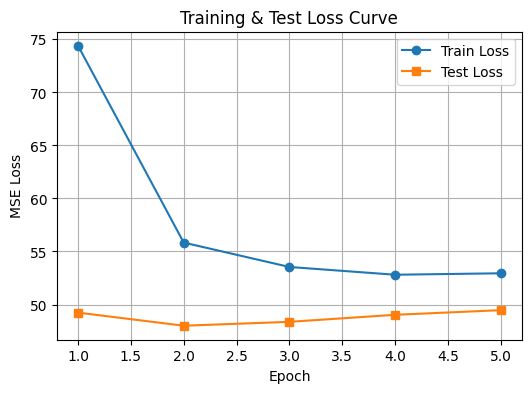

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.





Processing EO branch: s2
Epoch 1/5 -> Train Loss: 54.0113, Test Loss: 48.1734
Epoch 2/5 -> Train Loss: 50.1762, Test Loss: 48.1752
Epoch 3/5 -> Train Loss: 50.2753, Test Loss: 49.3503
Epoch 4/5 -> Train Loss: 49.3789, Test Loss: 48.0553
Epoch 5/5 -> Train Loss: 49.9487, Test Loss: 48.1278


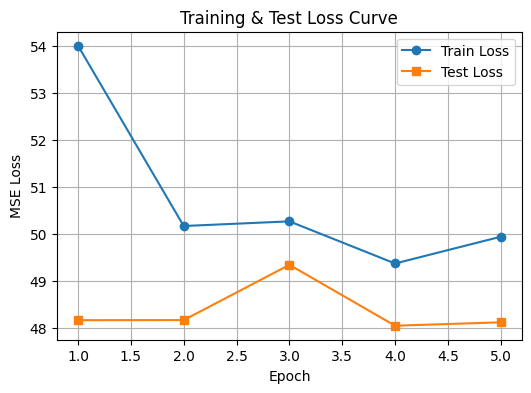

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: landsat
Epoch 1/5 -> Train Loss: 71.3967, Test Loss: 46.4844
Epoch 2/5 -> Train Loss: 56.9504, Test Loss: 45.5328
Epoch 3/5 -> Train Loss: 56.3413, Test Loss: 46.2305
Epoch 4/5 -> Train Loss: 50.6853, Test Loss: 47.1737
Epoch 5/5 -> Train Loss: 53.1020, Test Loss: 47.2930


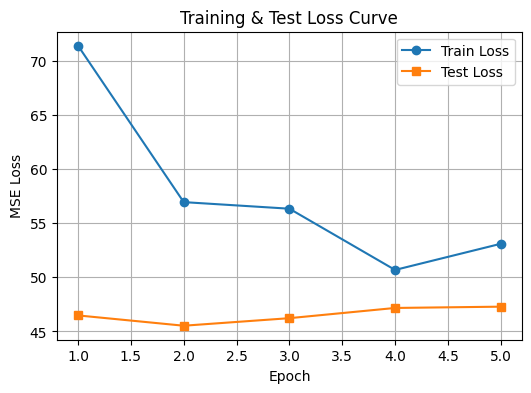

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: landsatidx
Epoch 1/5 -> Train Loss: 66.7651, Test Loss: 46.7489
Epoch 2/5 -> Train Loss: 53.6959, Test Loss: 45.5575
Epoch 3/5 -> Train Loss: 52.1071, Test Loss: 46.0311
Epoch 4/5 -> Train Loss: 51.5054, Test Loss: 46.6091
Epoch 5/5 -> Train Loss: 51.5499, Test Loss: 46.7992


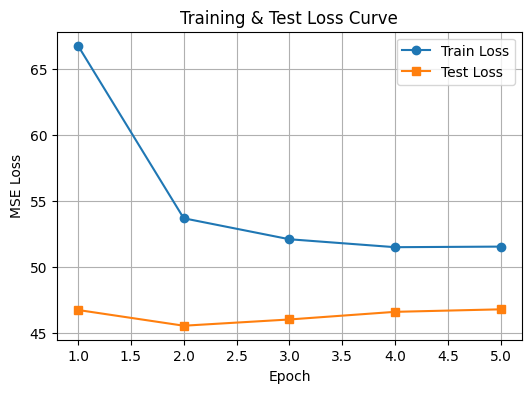

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: hls
Epoch 1/5 -> Train Loss: 69.9434, Test Loss: 46.4316
Epoch 2/5 -> Train Loss: 55.0698, Test Loss: 45.5485
Epoch 3/5 -> Train Loss: 52.5702, Test Loss: 46.3294
Epoch 4/5 -> Train Loss: 51.6797, Test Loss: 47.2225
Epoch 5/5 -> Train Loss: 51.7119, Test Loss: 47.6817


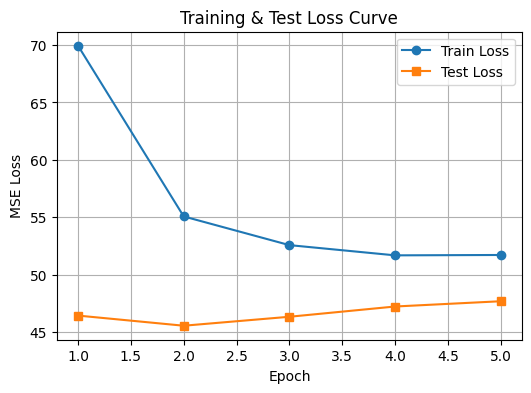

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: tcap
Epoch 1/5 -> Train Loss: 70.5715, Test Loss: 46.4627
Epoch 2/5 -> Train Loss: 55.6973, Test Loss: 45.5729
Epoch 3/5 -> Train Loss: 52.0198, Test Loss: 46.4360
Epoch 4/5 -> Train Loss: 50.0180, Test Loss: 47.3471
Epoch 5/5 -> Train Loss: 51.9875, Test Loss: 48.0430


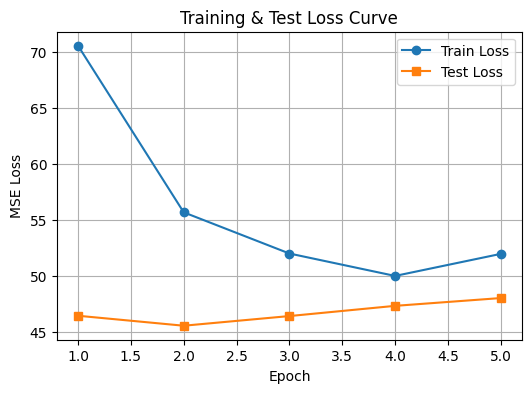

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: dem
Epoch 1/5 -> Train Loss: 74.3211, Test Loss: 46.7048
Epoch 2/5 -> Train Loss: 55.7520, Test Loss: 45.5452
Epoch 3/5 -> Train Loss: 49.8224, Test Loss: 46.5559
Epoch 4/5 -> Train Loss: 50.3722, Test Loss: 47.4071
Epoch 5/5 -> Train Loss: 55.6400, Test Loss: 48.0494


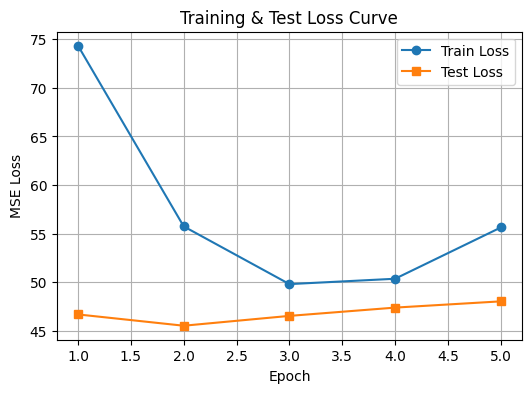

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing EO branch: s2idx
Epoch 1/5 -> Train Loss: 91.1309, Test Loss: 49.6191
Epoch 2/5 -> Train Loss: 65.8319, Test Loss: 47.6407
Epoch 3/5 -> Train Loss: 59.2001, Test Loss: 46.6237
Epoch 4/5 -> Train Loss: 55.7748, Test Loss: 46.4830
Epoch 5/5 -> Train Loss: 53.5926, Test Loss: 46.9157


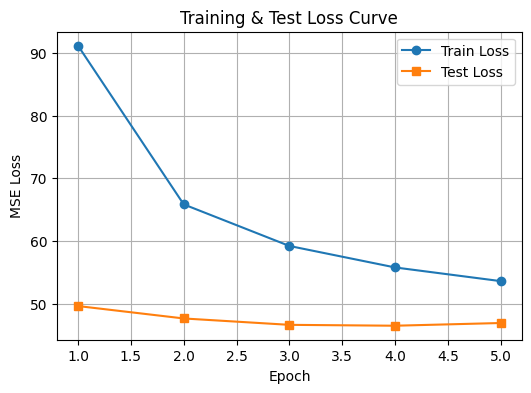

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [40]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader = test_loaders[branch_name]  # your separate test loader for generalization

#     # Infer number of channels from dataset
#     in_channels = train_loader.dataset[0][0].shape[0]

#     # Initialize custom ViT
#     model = ViTCustom(in_channels=in_channels)

#     # Train model and track both train & test loss
#     #11/17/approach # model = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)


#     # Extract embeddings from the train set (or you could use test set embeddings if desired)
#     embeddings, targets = extract_embeddings(model, train_loader, device=device)

#     # # Visualize in 3D using Plotly
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



# GEDI L1B Run Embedding  and viz

11/17 approach for DNN GEDI L1B

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class Waveform1DCNN(nn.Module):
#     def __init__(self, input_length=1024, embed_dim=128):
#         super().__init__()
#         self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
#         self.bn1 = nn.BatchNorm1d(32)
#         self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
#         self.bn2 = nn.BatchNorm1d(64)
#         self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
#         self.bn3 = nn.BatchNorm1d(128)

#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(128, embed_dim)

#     def forward(self, x):
#         # x: [B, 1, 1024]
#         x = F.gelu(self.bn1(self.conv1(x)))
#         x = F.gelu(self.bn2(self.conv2(x)))
#         x = F.gelu(self.bn3(self.conv3(x)))
#         x = self.pool(x).squeeze(-1)  # [B, 128]
#         x = self.fc(x)                # [B, embed_dim]
#         return x


In [ ]:
# from torchsummary import summary

# model = Waveform1DCNN(input_length=1024, embed_dim=128)
# summary(model, (1, 1024))


In [ ]:
# def train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device='cuda'):
#     """
#     Forward pass only to let model learn representation (optional self-supervised later)
#     """
#     modelrx.to(device)
#     modelrx.train()

#     for epoch in range(epochs):
#         for x in loader_rx:
#             x = x.to(device)  # [B,1,1024]
#             emb = modelrx(x)  # [B, embed_dim]
#         print(f"Epoch {epoch+1} completed")  # just progress
#     return modelrx


In [ ]:
# def extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device='cuda'):
#     modelrx.eval()
#     embeddings = []
#     with torch.no_grad():
#         for x in loader_rx:
#             x = x.to(device)
#             emb = modelrx(x)
#             embeddings.append(emb.cpu())
#     embeddings = torch.cat(embeddings, dim=0)  # [num_samples, embed_dim]
#     return embeddings


In [ ]:
# Approach for the CNN not the encoder

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate model
# modelrx = Waveform1DCNN(input_length=1024, embed_dim=128)

# # "Train" model (optional, just forward for embeddings)
# modelrx = train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device=device)

# # Extract embeddings
# embeddings = extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device=device)

# # Visualize with UMAP
# visualize_umap_3d(embeddings, torch.zeros(len(embeddings)), title="Waveform Latent UMAP 3D")



Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



# GEDI L1B Autoencoder -> embedding latent layers

In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveformEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)   # 1024 → 512
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2) # 512 → 256
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 5, stride=2, padding=2)# 256 → 128
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.AdaptiveAvgPool1d(1)   # 128 → 1
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = F.gelu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)     # [B, 128]
        z = self.fc(x)                   # [B, embed_dim]
        return z


class WaveformDecoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.fc = nn.Linear(embed_dim, 128)

        # decode upsampling branch
        self.up1 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)  # 1 → 2
        self.up2 = nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1)   # 2 → 4
        self.up3 = nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1)   # 4 → 8
        self.up4 = nn.ConvTranspose1d(16, 8, 4, stride=2, padding=1)    # 8 → 16
        self.up5 = nn.ConvTranspose1d(8, 4, 4, stride=2, padding=1)     # 16 → 32
        self.up6 = nn.ConvTranspose1d(4, 2, 4, stride=2, padding=1)     # 32 → 64
        self.up7 = nn.ConvTranspose1d(2, 1, 4, stride=2, padding=1)     # 64 → 128

        # interpolation to reach exactly 1024
        self.final = nn.Sequential(
            nn.Conv1d(1, 1, 5, padding=2),
            nn.GELU()
        )

    def forward(self, z):
        z = self.fc(z)                      # [B, 128]
        z = z.unsqueeze(-1)                # [B, 128, 1]

        x = F.gelu(self.up1(z))
        x = F.gelu(self.up2(x))
        x = F.gelu(self.up3(x))
        x = F.gelu(self.up4(x))
        x = F.gelu(self.up5(x))
        x = F.gelu(self.up6(x))
        x = F.gelu(self.up7(x))            # [B, 1, 128]

        x = F.interpolate(x, size=1024, mode='linear')  # ← FORCE 1024
        x = self.final(x)

        return x


class WaveformAutoencoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.encoder = WaveformEncoder(embed_dim)
        self.decoder = WaveformDecoder(embed_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


In [118]:
# 11/20 fix extract tensor from dict
def train_waveform_autoencoder(model, loader, epochs=5, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in loader:
            # Unpack tensor from dict
            x = batch["image"].to(device)  # shape [B, 1, 1024]

            optimizer.zero_grad()
            out, _ = model(x)  # ✅ unpack tuple (reconstruction, latent)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model





# def train_waveform_autoencoder(model, loader, epochs=20, lr=1e-3, device='cuda'):
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         for x in loader:
#             x = x.to(device)

#             optimizer.zero_grad()
#             x_recon, z = model(x)
#             loss = criterion(x_recon, x)

#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss/len(loader):.4f}")

#     return model


In [116]:
# 11/20 fix extract tensor from dict
def extract_waveform_embeddings(model, loader, device='cuda'):
    model.eval()
    embs = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            z = model.encoder(x)
            embs.append(z.cpu())
    return torch.cat(embs, dim=0)




# def extract_waveform_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embs = []
#     with torch.no_grad():
#         for x in loader:
#             x = x.to(device)
#             z = model.encoder(x)  # Use only encoder
#             embs.append(z.cpu())
#     return torch.cat(embs)


In [100]:
from torchsummary import summary

modelrx = WaveformAutoencoder(embed_dim=128).to(device)
summary(modelrx, input_size=(1, 1024))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 32, 512]             256
       BatchNorm1d-2              [-1, 32, 512]              64
            Conv1d-3              [-1, 64, 256]          10,304
       BatchNorm1d-4              [-1, 64, 256]             128
            Conv1d-5             [-1, 128, 128]          41,088
       BatchNorm1d-6             [-1, 128, 128]             256
 AdaptiveAvgPool1d-7               [-1, 128, 1]               0
            Linear-8                  [-1, 128]          16,512
   WaveformEncoder-9                  [-1, 128]               0
           Linear-10                  [-1, 128]          16,512
  ConvTranspose1d-11                [-1, 64, 2]          32,832
  ConvTranspose1d-12                [-1, 32, 4]           8,224
  ConvTranspose1d-13                [-1, 16, 8]           2,064
  ConvTranspose1d-14                [-1

# train and viz just waveform
works great just commented off to use the merged emdedding approach

In [45]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate autoencoder
# modelrx = WaveformAutoencoder(embed_dim=128)

# # Train autoencoder (unsupervised reconstruction)
# modelrx = train_waveform_autoencoder(modelrx, loader_rx, epochs=5, device=device)

# # Extract latent embeddings (use encoder only)
# embeddings = extract_waveform_embeddings(modelrx, loader_rx, device=device)

# # Visualize with UMAP (dummy labels = zeros)
# visualize_umap_3d(
#     embeddings,
#     torch.zeros(len(embeddings)),
#     title="Waveform Autoencoder Latent UMAP 3D"
# )


Epoch 1/5 Loss: 54702.6194
Epoch 2/5 Loss: 54220.8798
Epoch 3/5 Loss: 53776.7850
Epoch 4/5 Loss: 53397.5325
Epoch 5/5 Loss: 53022.4760


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



# Add all modaility Single run viz

In [72]:
import umap
import plotly.express as px

def visualize_umap_3d_string(embeddings, labels, title="UMAP 3D"):
    """
    embeddings : torch.Tensor or numpy array
        Shape [N, D]
    labels : numpy array of strings (modality names)
    """

    # Ensure embeddings → numpy
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    # UMAP reduction
    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    # Build interactive 3D scatter
    fig = px.scatter_3d(
        x=emb_3d[:, 0],
        y=emb_3d[:, 1],
        z=emb_3d[:, 2],
        color=labels,            # categorical colors
        title=title
    )

    fig.update_traces(marker=dict(size=4))
    fig.show()



Processing EO branch: s1
Epoch 1/5 -> Train Loss: 74.5803, Test Loss: 50.9314
Epoch 2/5 -> Train Loss: 59.0469, Test Loss: 48.3947
Epoch 3/5 -> Train Loss: 54.6589, Test Loss: 48.1018
Epoch 4/5 -> Train Loss: 53.3635, Test Loss: 48.7411
Epoch 5/5 -> Train Loss: 52.3749, Test Loss: 49.0519


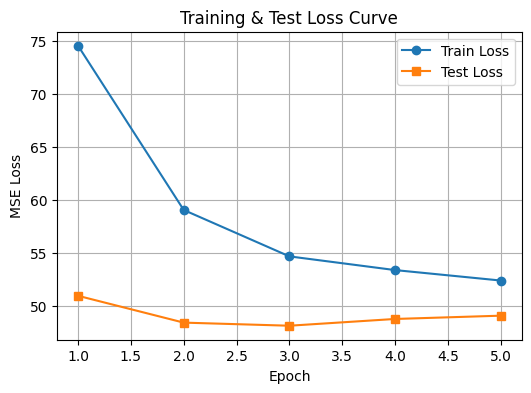


Processing EO branch: s2
Epoch 1/5 -> Train Loss: 57.8552, Test Loss: 48.4598
Epoch 2/5 -> Train Loss: 48.7681, Test Loss: 48.2392
Epoch 3/5 -> Train Loss: 48.8829, Test Loss: 48.5164
Epoch 4/5 -> Train Loss: 48.1154, Test Loss: 46.5306
Epoch 5/5 -> Train Loss: 45.7973, Test Loss: 44.9130


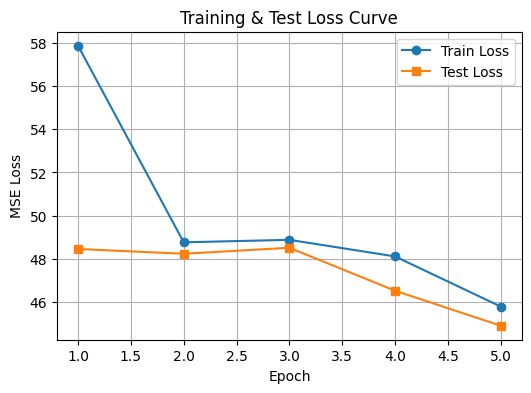


Processing EO branch: landsat
Epoch 1/5 -> Train Loss: 66.9282, Test Loss: 46.4403
Epoch 2/5 -> Train Loss: 53.8743, Test Loss: 45.5468
Epoch 3/5 -> Train Loss: 52.6388, Test Loss: 46.0869
Epoch 4/5 -> Train Loss: 53.7551, Test Loss: 47.6284
Epoch 5/5 -> Train Loss: 49.9344, Test Loss: 48.0683


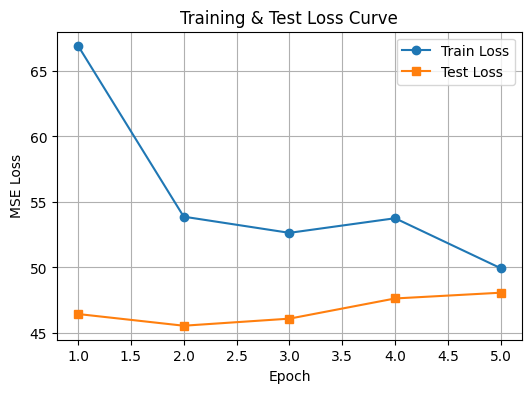


Processing EO branch: landsatidx
Epoch 1/5 -> Train Loss: 73.7301, Test Loss: 46.3879
Epoch 2/5 -> Train Loss: 56.7586, Test Loss: 45.5594
Epoch 3/5 -> Train Loss: 52.4740, Test Loss: 45.9018
Epoch 4/5 -> Train Loss: 52.1243, Test Loss: 46.7069
Epoch 5/5 -> Train Loss: 50.8989, Test Loss: 47.4790


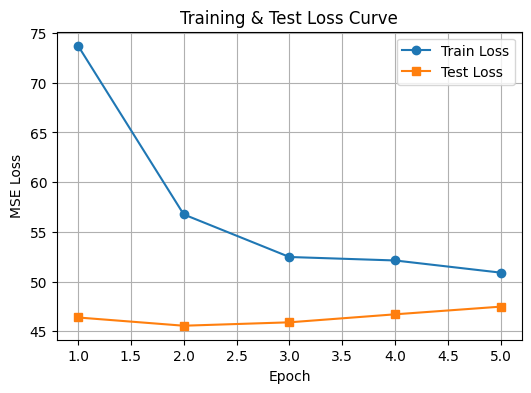


Processing EO branch: hls
Epoch 1/5 -> Train Loss: 72.9795, Test Loss: 46.6921
Epoch 2/5 -> Train Loss: 55.8618, Test Loss: 45.5441
Epoch 3/5 -> Train Loss: 53.0008, Test Loss: 46.0304
Epoch 4/5 -> Train Loss: 51.7697, Test Loss: 46.6738
Epoch 5/5 -> Train Loss: 51.8687, Test Loss: 47.6230


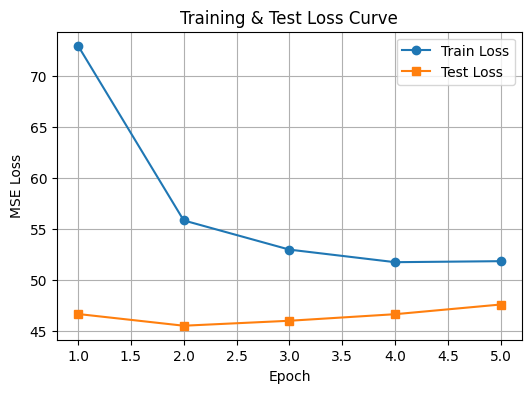


Processing EO branch: tcap
Epoch 1/5 -> Train Loss: 73.0460, Test Loss: 46.5170
Epoch 2/5 -> Train Loss: 55.7078, Test Loss: 45.5688
Epoch 3/5 -> Train Loss: 52.5463, Test Loss: 46.3416
Epoch 4/5 -> Train Loss: 51.6572, Test Loss: 46.7564
Epoch 5/5 -> Train Loss: 50.7035, Test Loss: 46.8710


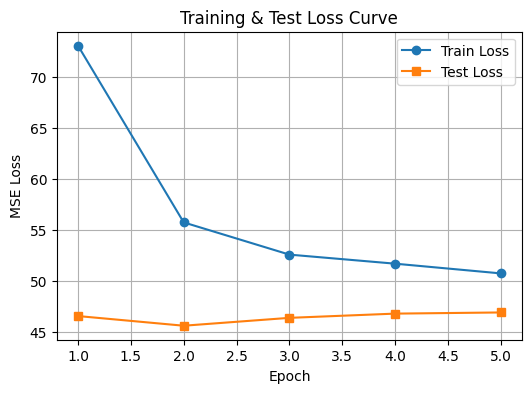


Processing EO branch: dem
Epoch 1/5 -> Train Loss: 66.0834, Test Loss: 46.5080
Epoch 2/5 -> Train Loss: 54.9826, Test Loss: 45.5529
Epoch 3/5 -> Train Loss: 52.6671, Test Loss: 45.9467
Epoch 4/5 -> Train Loss: 54.6097, Test Loss: 46.5246
Epoch 5/5 -> Train Loss: 54.2261, Test Loss: 46.7619


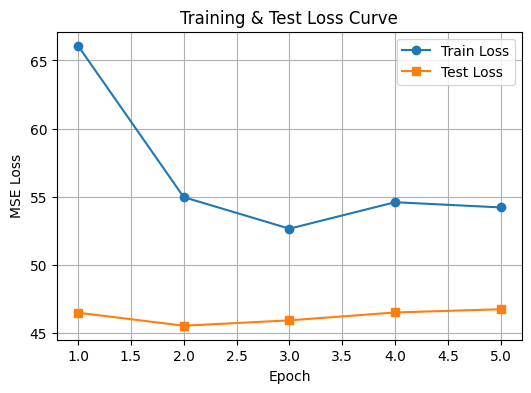


Processing EO branch: s2idx
Epoch 1/5 -> Train Loss: 87.4892, Test Loss: 51.3541
Epoch 2/5 -> Train Loss: 68.7025, Test Loss: 48.5949
Epoch 3/5 -> Train Loss: 61.4467, Test Loss: 46.9488
Epoch 4/5 -> Train Loss: 57.3090, Test Loss: 46.4531
Epoch 5/5 -> Train Loss: 54.0608, Test Loss: 46.6765


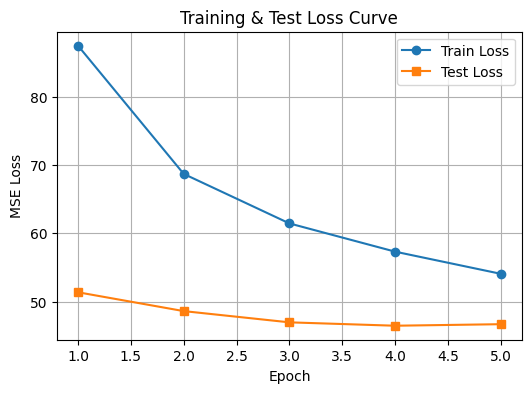

Epoch 1/5, Loss: 54521.0567
Epoch 2/5, Loss: 54068.5856
Epoch 3/5, Loss: 53668.3445
Epoch 4/5, Loss: 53300.4495
Epoch 5/5, Loss: 52929.5548


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




UMAP Modalities included:
 • s1
 • s2
 • landsat
 • landsatidx
 • hls
 • tcap
 • dem
 • s2idx
 • waveform


In [119]:
import torch
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ----------------------------------
# Collect all embeddings, store RH targets separately
# ----------------------------------
all_embeddings = {}
all_RH_targets  = {}
all_paths       = {}   # NEW: store paths

modality_labels = []

for branch_name in train_loaders.keys():
    print(f"\nProcessing EO branch: {branch_name}")

    train_loader = train_loaders[branch_name]
    test_loader  = test_loaders[branch_name]

    # Build ViT encoder
    in_channels = train_loader.dataset[0]["image"].shape[0]
    model = ViTCustom(in_channels=in_channels)

    # Train
    model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

    # Extract embeddings + paths
    emb, targets, paths = extract_embeddings(model, train_loader, device=device)

    all_embeddings[branch_name] = emb
    all_RH_targets[branch_name] = targets
    all_paths[branch_name] = paths

    modality_labels.extend([branch_name] * emb.shape[0])


# ----------------------------------
# Add waveform autoencoder embeddings
# ----------------------------------

wave_model = WaveformAutoencoder(embed_dim=128)
wave_model = train_waveform_autoencoder(wave_model, loader_rx, epochs=5, device=device)

wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)

all_embeddings["waveform"] = wave_emb.cpu()
modality_labels.extend(["waveform"] * wave_emb.shape[0])


# ----------------------------------
# Build final UMAP input
# ----------------------------------

emb_all = torch.cat([all_embeddings[k] for k in all_embeddings.keys()], dim=0)
labels_all = np.array(modality_labels)  # strings, not integers


# ----------------------------------
# UMAP Visualization with categorical colors
# ----------------------------------

visualize_umap_3d_string(
    emb_all,
    labels_all,           # now strings → categorical colors
    title="UMAP 3D - All EO Modalities + Waveform"
)

print("\nUMAP Modalities included:")
for name in all_embeddings.keys():
    print(" •", name)


In [ ]:
# all_paths

In [ ]:
# all_embeddings

#combine file paths, (All EO  including Waveform) embbedding, and df_wave
Make a master list to support flex fusion

In [108]:
import pandas as pd
import torch

# 1️⃣ Start with empty fusion dataframe
df_valid_fusion_prep = pd.DataFrame(columns=["modality", "embedding", "target", "path"])

# 2️⃣ Add EO embeddings
for mod in all_embeddings.keys():
    if mod == "waveform":
        continue  # skip waveform for now
    emb_tensor = all_embeddings[mod]   # shape [N, embed_dim]
    targets = torch.tensor([float(t) for t in all_RH_targets[mod]], dtype=torch.float32)
    paths = all_paths[mod]

    df_mod = pd.DataFrame({
        "modality": [mod] * len(emb_tensor),
        "embedding": [emb for emb in emb_tensor],
        "target": [t for t in targets],
        "path": paths
    })
    df_valid_fusion_prep = pd.concat([df_valid_fusion_prep, df_mod], ignore_index=True)

# 3️⃣ Add waveform embeddings
# Ensure targets tensor exists for waveform
all_RH_targets["waveform"] = torch.tensor(df_wave["target"].values, dtype=torch.float32)

wave_df = pd.DataFrame({
    "modality": ["waveform"] * len(df_wave),
    "embedding": [emb for emb in wave_emb],       # waveform embeddings tensor
    "target": [t for t in all_RH_targets["waveform"]],
    "path": [f"waveform_idx_{i}" for i in range(len(df_wave))]
})

df_valid_fusion_prep = pd.concat([df_valid_fusion_prep, wave_df], ignore_index=True)

# 4️⃣ Quick summary
print("Fusion DF shape:", df_valid_fusion_prep.shape)
print("\nSamples per modality:")
print(df_valid_fusion_prep.groupby("modality")["modality"].count())

# Print first 3 embeddings/paths per modality
for mod in df_valid_fusion_prep["modality"].unique():
    sub = df_valid_fusion_prep[df_valid_fusion_prep["modality"] == mod]
    print(f"\n--- Modality: {mod} ---")
    print("Number of samples:", len(sub))
    print("First 3 embeddings shapes:")
    for i, emb in enumerate(sub["embedding"].iloc[:3]):
        print(f"  Sample {i}: {emb.shape}")
    print("First 3 paths/identifiers:")
    print(list(sub["path"].iloc[:3]))


Fusion DF shape: (5454, 4)

Samples per modality:
modality
dem            194
hls            192
landsat        194
landsatidx     194
s1             165
s2             371
s2idx          104
tcap           194
waveform      3846
Name: modality, dtype: int64

--- Modality: s1 ---
Number of samples: 165
First 3 embeddings shapes:
  Sample 0: torch.Size([128])
  Sample 1: torch.Size([128])
  Sample 2: torch.Size([128])
First 3 paths/identifiers:
['/content/processed_32x32_normalized/s1_train_GEDI_L2A_2021135083748_148_block_6003894.tif', '/content/processed_32x32_normalized/s1_train_GEDI_L2A_2022358084911_1837_block_6023896.tif', '/content/processed_32x32_normalized/s1_train_GEDI_L2A_2022358084911_1818_block_6013895.tif']

--- Modality: s2 ---
Number of samples: 371
First 3 embeddings shapes:
  Sample 0: torch.Size([128])
  Sample 1: torch.Size([128])
  Sample 2: torch.Size([128])
First 3 paths/identifiers:
['/content/processed_32x32_normalized/s2_train_GEDI_L2A_2020196021509_940_block_5

# Fusion Transformer

In [126]:
import torch
import numpy as np

# Ensure modalities_order matches your columns in df_valid_fusion_prep
modalities_order = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx','waveform']
embed_dim = 128
num_modalities = len(modalities_order)

# Get unique samples (using 'path' or 'sample_idx')
if 'path' in df_valid_fusion_prep.columns:
    unique_samples = df_valid_fusion_prep['path'].unique()
else:
    unique_samples = df_valid_fusion_prep['sample_idx'].unique()

X_seq = []
mask_seq = []
y_seq = []

for samp in unique_samples:
    row = df_valid_fusion_prep[df_valid_fusion_prep['path']==samp] if 'path' in df_valid_fusion_prep else df_valid_fusion_prep[df_valid_fusion_prep['sample_idx']==samp]

    seq_emb = []
    seq_mask = []

    for mod in modalities_order:
        mod_row = row[row['modality']==mod]
        if not mod_row.empty:
            seq_emb.append(mod_row.iloc[0]['embedding'])  # tensor([128])
            seq_mask.append(1)
        else:
            seq_emb.append(torch.zeros(embed_dim))
            seq_mask.append(0)

    X_seq.append(torch.stack(seq_emb))       # shape (num_modalities, embed_dim)
    mask_seq.append(torch.tensor(seq_mask))  # shape (num_modalities,)
    y_seq.append(row.iloc[0]['target'])      # supervised target

# Stack into final tensors
X_seq = torch.stack(X_seq)      # (num_samples, num_modalities, embed_dim)
mask_seq = torch.stack(mask_seq)  # (num_samples, num_modalities)
y_seq = torch.tensor(y_seq, dtype=torch.float32)  # (num_samples,)


In [130]:
import torch.nn as nn
import torch.nn.functional as F

class TransformerFusion(nn.Module):
    def __init__(self, embed_dim=128, num_modalities=9, hidden_dim=256, mlp_dim=128, nhead=4, num_layers=2):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_modalities = num_modalities

        # Optional: LayerNorm on embeddings
        self.ln_in = nn.LayerNorm(embed_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=hidden_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # MLP after transformer
        self.mlp1 = nn.Linear(embed_dim, mlp_dim)
        self.mlp2 = nn.Linear(mlp_dim, mlp_dim)

        # Gaussian Head
        self.mu_head = nn.Linear(mlp_dim, 1)
        self.sigma_head = nn.Linear(mlp_dim, 1)

    def forward(self, x, mask=None):
        """
        x: (B, num_modalities, embed_dim)
        mask: (B, num_modalities) -> 1 for valid, 0 for missing
        """
        x = self.ln_in(x)

        if mask is not None:
            # Transformer expects attn_mask: True -> ignore, False -> attend
            # So invert: mask==1 -> False (attend), mask==0 -> True (ignore)
            attn_mask = (mask == 0)
        else:
            attn_mask = None

        x = self.transformer(x, src_key_padding_mask=attn_mask)  # (B, num_modalities, embed_dim)

        # Pool modalities (mean of valid embeddings)
        if mask is not None:
            mask_f = mask.unsqueeze(-1)  # (B, num_modalities, 1)
            x = (x * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1e-6)
        else:
            x = x.mean(dim=1)

        # MLP
        x = F.gelu(self.mlp1(x))
        x = F.gelu(self.mlp2(x))

        # Gaussian head
        mu = self.mu_head(x).squeeze(-1)      # (B,)
        sigma = F.softplus(self.sigma_head(x)).squeeze(-1)  # (B,)

        return mu, sigma


In [131]:
model = TransformerFusion(embed_dim=128, num_modalities=len(modalities_order)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = lambda mu, sigma, y: ((mu - y)**2 / (2*sigma**2) + torch.log(sigma)).mean()  # Gaussian NLL

X_seq = X_seq.to(device)
mask_seq = mask_seq.to(device)
y_seq = y_seq.to(device)

epochs = 10

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    mu, sigma = model(X_seq, mask_seq)
    loss = criterion(mu, sigma, y_seq)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 1/10, Loss: 42.3170
Epoch 2/10, Loss: 31.8055
Epoch 3/10, Loss: 24.1891
Epoch 4/10, Loss: 17.8654
Epoch 5/10, Loss: 12.7204
Epoch 6/10, Loss: 8.7883
Epoch 7/10, Loss: 6.0710
Epoch 8/10, Loss: 4.3744
Epoch 9/10, Loss: 3.3571
Epoch 10/10, Loss: 2.7803


older https://chatgpt.com/c/69177d0d-6574-8330-9022-d71e12822e03

https://chatgpt.com/c/691b75d9-6dbc-8332-aec5-832409aaf0af